# 07 — Behavioral Differentiation Analysis

How do cheater/bot trajectories actually **differ** from legit behavior?
Notebook 05 established *which signals matter* (feature importance).
This notebook answers *how* the distributions differ — the signal BehaviorDNA's models learn from.

| Dataset | Source | Analysis |
|---|---|---|
| **CS2CD** | [`CS2CD/CS2CD.Counter-Strike_2_Cheat_Detection`](https://huggingface.co/datasets/CS2CD/CS2CD.Counter-Strike_2_Cheat_Detection) | Feature distributions, statistical tests, PCA+UMAP, aim-pattern overlays |
| **CaptchaSolve30k** | [`Capycap-AI/CaptchaSolve30k`](https://huggingface.co/datasets/Capycap-AI/CaptchaSolve30k) | Trajectory overlays by game type, Kruskal-Wallis across contexts |

**Setup — imports & data loading.**
Loads all libraries used throughout the notebook (`umap`, `scipy.stats`, `PCA`, `StandardScaler`, `seaborn`, `matplotlib`, `pandas`, `numpy`) and reads the three pre-cached datasets into memory: CS2CD (50 k game ticks, cheat label), CaptchaSolve30k (20 k CAPTCHA sessions, game-type label), and BehaviorDNA training windows (own recordings). Prints row/column counts and class balance as a quick sanity-check.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import umap
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

from pipeline.features.run import FEATURE_COLS

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

CS2CD_PARQUET   = ROOT / "data" / "external" / "cs2cd"     / "cs2cd_balanced_25000.parquet"
CAPTCHA_PARQUET = ROOT / "data" / "external" / "captcha30k" / "captcha30k.parquet"
BDNA_PARQUET    = ROOT / "data" / "splits" / "train.parquet"

cs2      = pd.read_parquet(CS2CD_PARQUET)
cap_raw  = pd.read_parquet(CAPTCHA_PARQUET)
bdna     = pd.read_parquet(BDNA_PARQUET)

print(f"CS2CD:          {cs2.shape}  | cheater_present: {cs2['cheater_present'].value_counts().to_dict()}")
print(f"CaptchaSolve30k:{cap_raw.shape}")
print(f"BehaviorDNA:    {bdna.shape}")

CS2CD:          (50000, 226)  | cheater_present: {0: 25000, 1: 25000}
CaptchaSolve30k:(20000, 9)
BehaviorDNA:    (36, 26)


**Helper — `session_kinematics()`.**
Converts a raw `tickInputs` array (list of `{x, y, sampleIndex}` dicts sampled at 240 Hz) into five scalar kinematic features: `speed_mean`, `speed_std`, `accel_mean`, `accel_std`, and `jitter`. Used later for CaptchaSolve30k analysis (Section D). Copied inline from notebook 05 so this notebook is fully self-contained.

In [2]:
# session_kinematics — copied from notebook 05 (notebooks are standalone)
DT = 1.0 / 240.0

def session_kinematics(tick_inputs):
    """Return kinematic feature dict or None if input is too short."""
    if tick_inputs is None:
        return None
    try:
        n = len(tick_inputs)
    except TypeError:
        return None
    if n < 3:
        return None
    try:
        df = pd.DataFrame(list(tick_inputs)).sort_values("sampleIndex").reset_index(drop=True)
    except Exception:
        return None
    dx = df["x"].diff().dropna()
    dy = df["y"].diff().dropna()
    dist  = np.sqrt(dx**2 + dy**2)
    speed = dist / DT
    accel = speed.diff().abs().dropna()
    total_path = dist.sum()
    euclidean  = np.sqrt((df["x"].iloc[-1] - df["x"].iloc[0])**2 + (df["y"].iloc[-1] - df["y"].iloc[0])**2)
    return {
        "speed_mean": float(speed.mean()),
        "speed_std":  float(speed.std()),
        "accel_mean": float(accel.mean()),
        "accel_std":  float(accel.std()),
        "jitter":     float(total_path / max(euclidean, 1e-9)),
        "game_type":  None,
    }

print("session_kinematics ready")

session_kinematics ready


---
## Section A — CS2CD: Feature Distributions by Cheat Label

We focus on the **10 BehaviorDNA-adjacent columns** — the per-tick behavioral input signals
that most directly mirror BehaviorDNA's feature space.
For each feature: violin plot split by `cheater_present`, then a ranked statistical test table.

**Violin plots — BehaviorDNA-adjacent feature distributions.**
For each of the 10 per-tick signals that most directly parallel BehaviorDNA's feature space (`usercmd_mouse_dx/dy`, `yaw`, `pitch`, `FORWARD/BACK/LEFT/RIGHT`, `FIRE`, `shots_fired`), draws a split violin coloured by class (blue = legit, red = cheat). Outliers beyond the 1st/99th percentile are clipped so the body shape is readable. The inner quartile lines show median and IQR. A wider or differently-shaped body means the distribution differs between classes — visual evidence of discriminative signal.

/tmp/ipykernel_119804/1678882631.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_119804/1678882631.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_119804/1678882631.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_119804/1678882631.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_119804/1678882631.py:

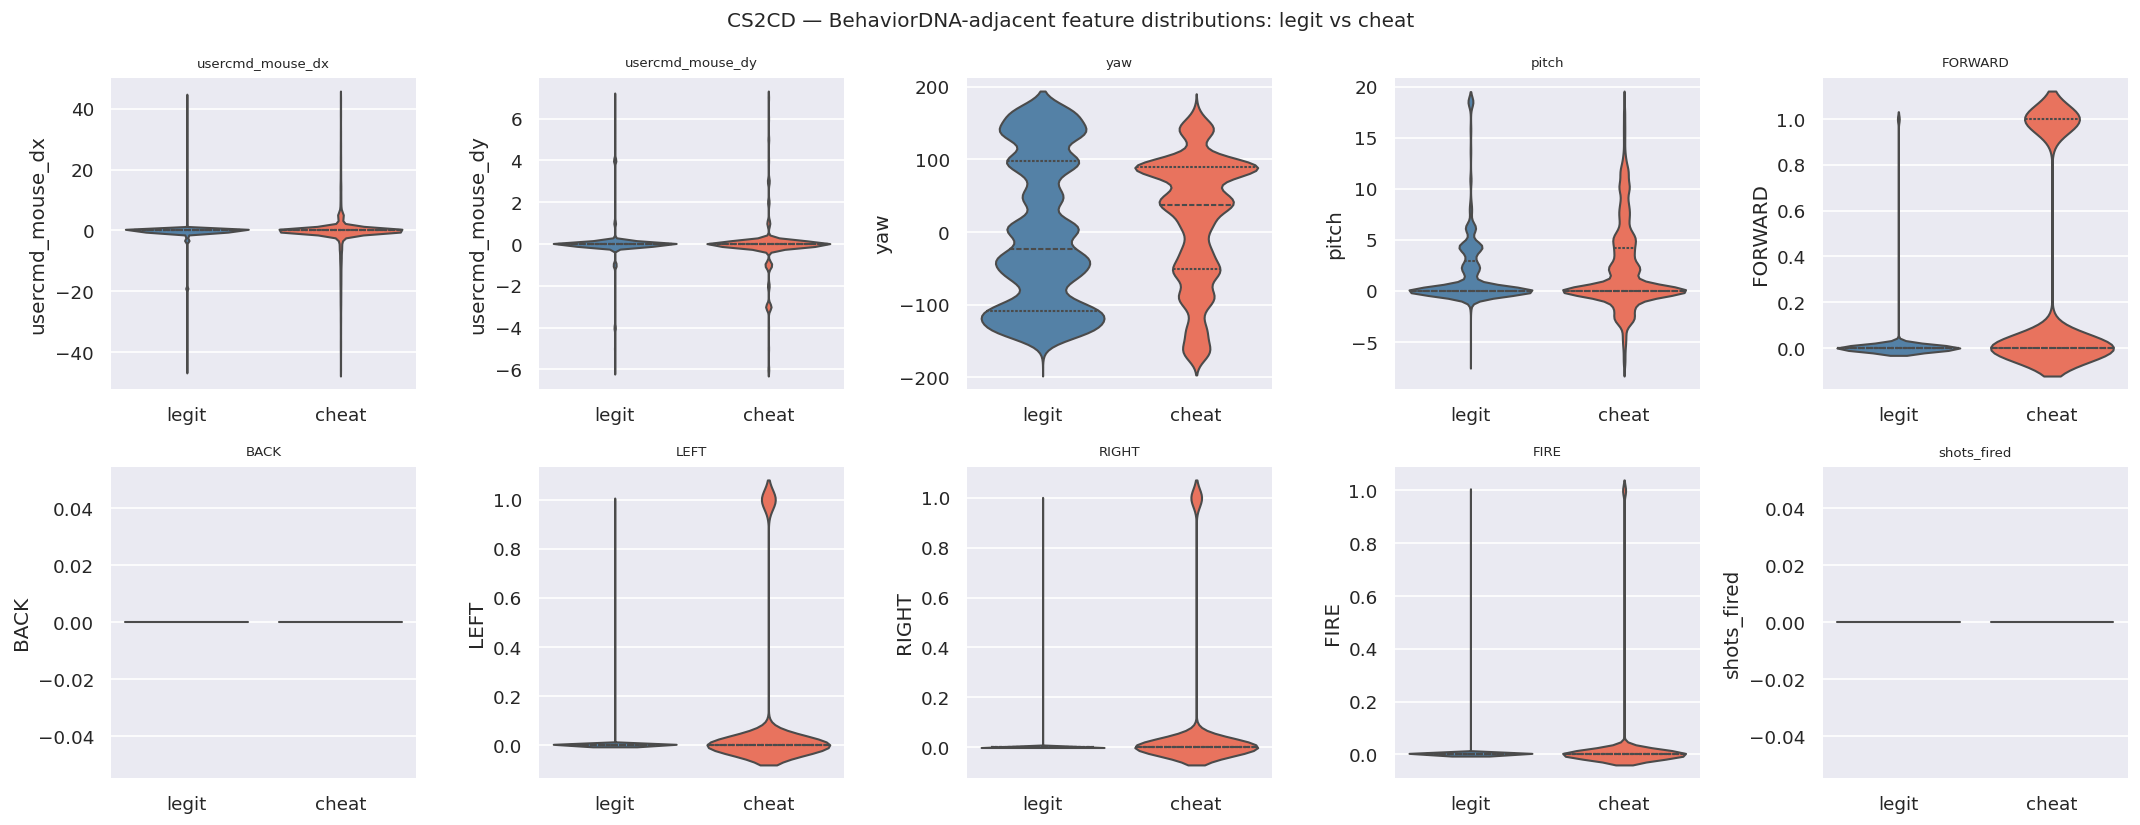

In [3]:
BDNA_ADJACENT = [
    "usercmd_mouse_dx", "usercmd_mouse_dy",
    "yaw", "pitch",
    "FORWARD", "BACK", "LEFT", "RIGHT",
    "FIRE", "shots_fired",
]
# Keep only columns that exist and have enough non-NaN values
available = [c for c in BDNA_ADJACENT if c in cs2.columns and cs2[c].notna().sum() > 1000]

# Cast label to string so seaborn palette dict keys match
cs2["label"] = cs2["cheater_present"].map({0: "legit", 1: "cheat"})

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for ax, col in zip(axes, available):
    # Cast to float to handle boolean columns (FORWARD, BACK, FIRE, etc.)
    subset = cs2[[col, "label"]].copy()
    subset[col] = subset[col].astype(float)
    subset = subset.dropna()
    hi = subset[col].quantile(0.99)
    lo = subset[col].quantile(0.01)
    subset = subset[(subset[col] >= lo) & (subset[col] <= hi)]
    sns.violinplot(
        data=subset, x="label", y=col,
        order=["legit", "cheat"],
        palette={"legit": "steelblue", "cheat": "tomato"},
        inner="quartile", ax=ax,
    )
    ax.set_title(col, fontsize=8)
    ax.set_xlabel("", fontsize=7)

for ax in axes[len(available):]:
    ax.set_visible(False)

fig.suptitle("CS2CD — BehaviorDNA-adjacent feature distributions: legit vs cheat", fontsize=12)
plt.tight_layout()
plt.show()

**Mann-Whitney U test — statistical significance ranking.**
Runs a non-parametric two-sample test on every numeric column in CS2CD (≈ 140 features), comparing the legit vs cheat distributions. Reports the top-20 ranked by **effect size** (rank-biserial correlation `r = |1 − 2U/(n₁×n₂)|`, range 0–1) rather than p-value, because with 50 k rows almost everything is statistically significant regardless of practical importance. BehaviorDNA-adjacent features are flagged with ✓.

In [4]:
# Mann-Whitney U test for every numeric feature — rank by effect size
num_cols = cs2.select_dtypes(include="number").columns.tolist()
num_cols = [c for c in num_cols if c != "cheater_present"]

legit = cs2[cs2["cheater_present"] == 0]
cheat = cs2[cs2["cheater_present"] == 1]

results = []
for col in num_cols:
    a = legit[col].dropna()
    b = cheat[col].dropna()
    if len(a) < 20 or len(b) < 20:
        continue
    u_stat, p_val = stats.mannwhitneyu(a, b, alternative="two-sided")
    # Rank-biserial correlation as effect size: r = 1 - 2U/(n1*n2)
    effect = abs(1 - 2 * u_stat / (len(a) * len(b)))
    results.append({"feature": col, "p_value": p_val, "effect_size": effect,
                    "bdna_adjacent": col in BDNA_ADJACENT})

mw = pd.DataFrame(results).sort_values("effect_size", ascending=False).reset_index(drop=True)

top20 = mw.head(20).copy()
top20["p_value"] = top20["p_value"].map("{:.2e}".format)
top20["effect_size"] = top20["effect_size"].map("{:.4f}".format)
top20["bdna_adjacent"] = top20["bdna_adjacent"].map({True: "✓", False: ""})
print("Top-20 features by Mann-Whitney effect size (rank-biserial correlation):")
top20

Top-20 features by Mann-Whitney effect size (rank-biserial correlation):


,feature,p_value,effect_size,bdna_adjacent
0,entity_id,0.00e+00,1.0000,
1,match_making_mode,0.00e+00,1.0000,
2,num_terrorist_timeouts,0.00e+00,1.0000,
3,warmup_period_end,0.00e+00,1.0000,
4,terrorist_timeout_remaining,0.00e+00,1.0000,
5,warmup_period_start,0.00e+00,1.0000,
6,num_ct_timeouts,0.00e+00,1.0000,
7,comp_rank_type,0.00e+00,1.0000,
8,Z,0.00e+00,0.9975,
9,game_time,0.00e+00,0.9746,


### Reading the table

**Effect size** is the rank-biserial correlation `r = |1 − 2U / (n₁ × n₂)|`.
It ranges 0–1: `0` = no difference, `1` = complete separation between classes.
Values above `0.1` are generally considered meaningful; above `0.3` are large.

**`p_value`** tests whether the difference could be due to chance (50k rows makes almost
everything significant — rely on effect size for practical importance).

**`bdna_adjacent ✓`** marks features that directly parallel BehaviorDNA's behavioral signals.

---
## Section B — CS2CD: PCA + UMAP Separation

Can we visually separate cheaters from legit players in 2D?
PCA captures linear variance; UMAP reveals non-linear cluster structure.
Clear separation validates that the feature space is discriminative — the signal is real.

**PCA + UMAP — 2-D separation of legit vs cheat.**
Scales all ~140 numeric features to zero-mean / unit-variance (`StandardScaler`), then projects to 2-D using two methods side-by-side.
**PCA** (left) runs on the full 50 k rows — fast, linear projection.
**UMAP** (right) uses a balanced 5 k subsample (2.5 k per class) to keep runtime under 10 seconds; the visual cluster structure is the same as on 50 k. The result is cached to `data/external/cs2cd/umap_5k.npy` so every subsequent run loads instantly.
Both plots colour legit blue and cheat red.

In [ ]:
feat_cols = [c for c in num_cols if c in cs2.columns]
X = cs2[feat_cols].fillna(0).values
y = cs2["cheater_present"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA on full 50k rows (fast — seconds)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA variance explained: PC1={pca.explained_variance_ratio_[0]:.1%}  PC2={pca.explained_variance_ratio_[1]:.1%}")

# UMAP: subsample to 5k rows (2.5k per class) — same visual result, ~20s instead of 2 min.
# Cache to disk so subsequent runs are instant.
UMAP_CACHE = ROOT / "data" / "external" / "cs2cd" / "umap_5k.npy"
UMAP_Y_CACHE = ROOT / "data" / "external" / "cs2cd" / "umap_5k_y.npy"

if UMAP_CACHE.exists():
    print("Loading cached UMAP embedding...")
    X_umap = np.load(UMAP_CACHE)
    y_umap = np.load(UMAP_Y_CACHE)
else:
    print("Fitting UMAP on 5k subsample (2.5k per class)...")
    rng = np.random.default_rng(42)
    idx_legit = rng.choice(np.where(y == 0)[0], size=2500, replace=False)
    idx_cheat = rng.choice(np.where(y == 1)[0], size=2500, replace=False)
    idx_sub = np.concatenate([idx_legit, idx_cheat])
    X_sub = X_scaled[idx_sub]
    y_umap = y[idx_sub]
    reducer = umap.UMAP(n_components=2, random_state=42, n_jobs=1)
    X_umap = reducer.fit_transform(X_sub)
    np.save(UMAP_CACHE, X_umap)
    np.save(UMAP_Y_CACHE, y_umap)
    print("UMAP done — cached to disk.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA scatter (full 50k)
for label, color, name in [(0, "steelblue", "Legit"), (1, "tomato", "Cheat")]:
    mask = y == label
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, alpha=0.15, s=4, label=name)
axes[0].set_title(f"PCA  (PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%})")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(markerscale=4)

# UMAP scatter (5k subsample)
for label, color, name in [(0, "steelblue", "Legit"), (1, "tomato", "Cheat")]:
    mask = y_umap == label
    axes[1].scatter(X_umap[mask, 0], X_umap[mask, 1], c=color, alpha=0.3, s=6, label=name)
axes[1].set_title("UMAP  (5k subsample — 2.5k per class)")
axes[1].set_xlabel("UMAP-1")
axes[1].set_ylabel("UMAP-2")
axes[1].legend(markerscale=4)

fig.suptitle("CS2CD — PCA vs UMAP: legit (blue) vs cheat (red)", fontsize=12)
plt.tight_layout()
plt.show()

**PCA feature loadings — what drives each principal component.**
Shows the 10 features with the highest absolute weight on PC1 and PC2 as horizontal bar charts. Bars in **tomato** are BehaviorDNA-adjacent features; steelblue bars are other CS2CD-specific columns. If BehaviorDNA-adjacent features dominate, it confirms that raw input signals (not just game-state metadata) are the primary axis of variation between classes.

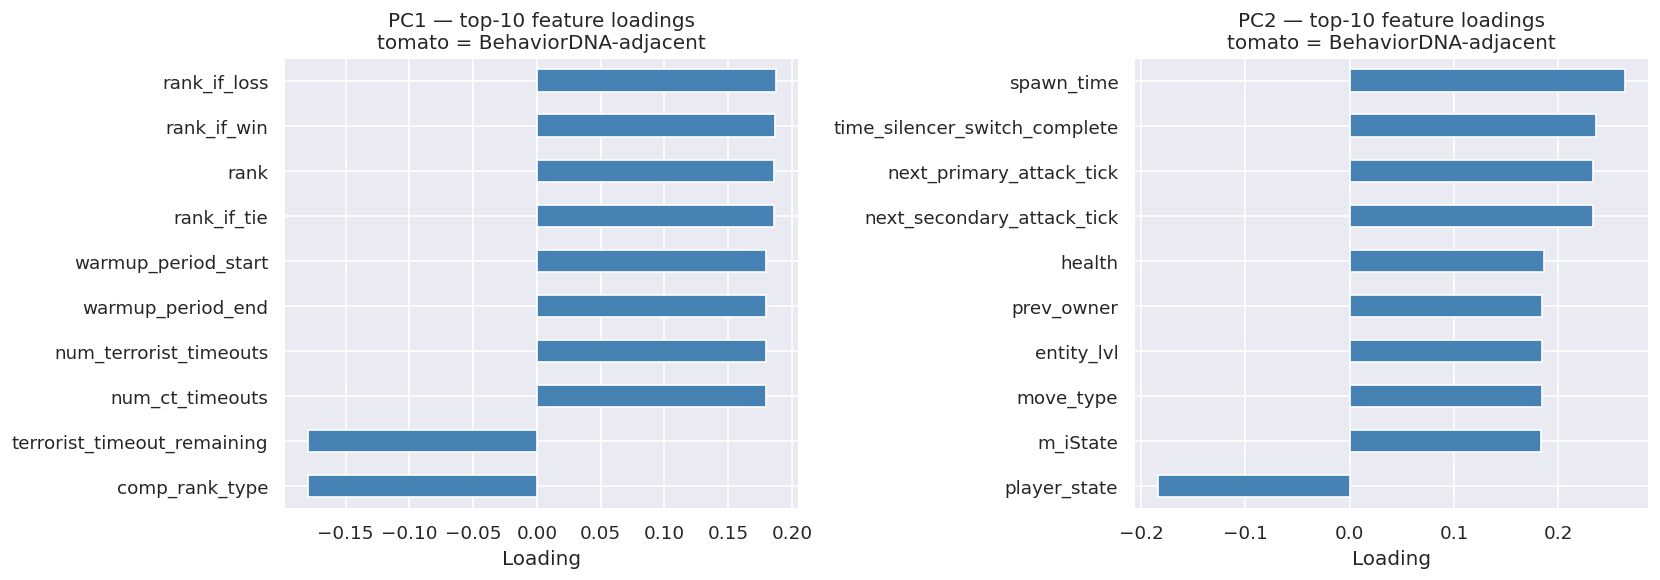

In [6]:
# PCA feature loadings — which features drive PC1 and PC2?
loadings = pd.DataFrame(pca.components_.T, index=feat_cols, columns=["PC1", "PC2"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pc in zip(axes, ["PC1", "PC2"]):
    top = loadings[pc].abs().nlargest(10).index
    vals = loadings.loc[top, pc].sort_values()
    bar_colors = ["tomato" if f in BDNA_ADJACENT else "steelblue" for f in vals.index]
    vals.plot.barh(ax=ax, color=bar_colors)
    ax.set_title(f"{pc} — top-10 feature loadings\ntomato = BehaviorDNA-adjacent")
    ax.set_xlabel("Loading")

plt.tight_layout()
plt.show()

---
## Section C — CS2CD: Aim-Pattern Trajectory Overlays

View angles (`usercmd_viewangle_x` = yaw, `usercmd_viewangle_y` = pitch) give us
an **aim map** per player — where they were looking over the course of their ticks.

Bots often show mechanical straight-line sweeps or tight repetitive clusters.
Human aim shows erratic, organic scatter with natural micro-adjustments.

**Column availability check — view-angle fallback.**
The preferred angle columns (`usercmd_viewangle_x`, `usercmd_viewangle_y`) store the player's absolute view direction at each tick and give the cleanest aim map. This cell verifies they are present and have enough non-null values (≥ 5 000). If not, it falls back to `yaw` / `pitch` which carry equivalent information in a different encoding.

In [7]:
VIEW_X = "usercmd_viewangle_x"
VIEW_Y = "usercmd_viewangle_y"

has_view = VIEW_X in cs2.columns and VIEW_Y in cs2.columns
print(f"{VIEW_X} available: {has_view}")
if has_view:
    print(f"Non-null counts: {VIEW_X}={cs2[VIEW_X].notna().sum():,}  {VIEW_Y}={cs2[VIEW_Y].notna().sum():,}")

# Fall back to yaw/pitch if viewangle columns are too sparse
if not has_view or cs2[VIEW_X].notna().sum() < 5000:
    VIEW_X, VIEW_Y = "yaw", "pitch"
    print(f"Falling back to yaw/pitch  (non-null: {cs2[VIEW_X].notna().sum():,})")

usercmd_viewangle_x available: True
Non-null counts: usercmd_viewangle_x=49,980  usercmd_viewangle_y=49,980


**Aim-map overlays — where each player looked across all their ticks.**
Plots view-angle X (horizontal rotation) vs view-angle Y (vertical tilt) as a 2-D scatter + connecting line for 3 legit players (blue, rows where `cheater_present=0`) and 3 cheat players (red, rows where `cheater_present=1`). Note: the same `steamid` appears in both legit and cheat matches in CS2CD, so each player's trajectory is filtered to only the rows matching their shown label.
Human aim typically shows organic scatter with micro-adjustments; aimbot trajectories often show unnaturally straight sweeps or mechanically repeated clusters.

Legit players: ['Player_7', 'Player_1', 'Player_4']
Cheat players: ['Player_8', 'Player_9', 'Player_7']


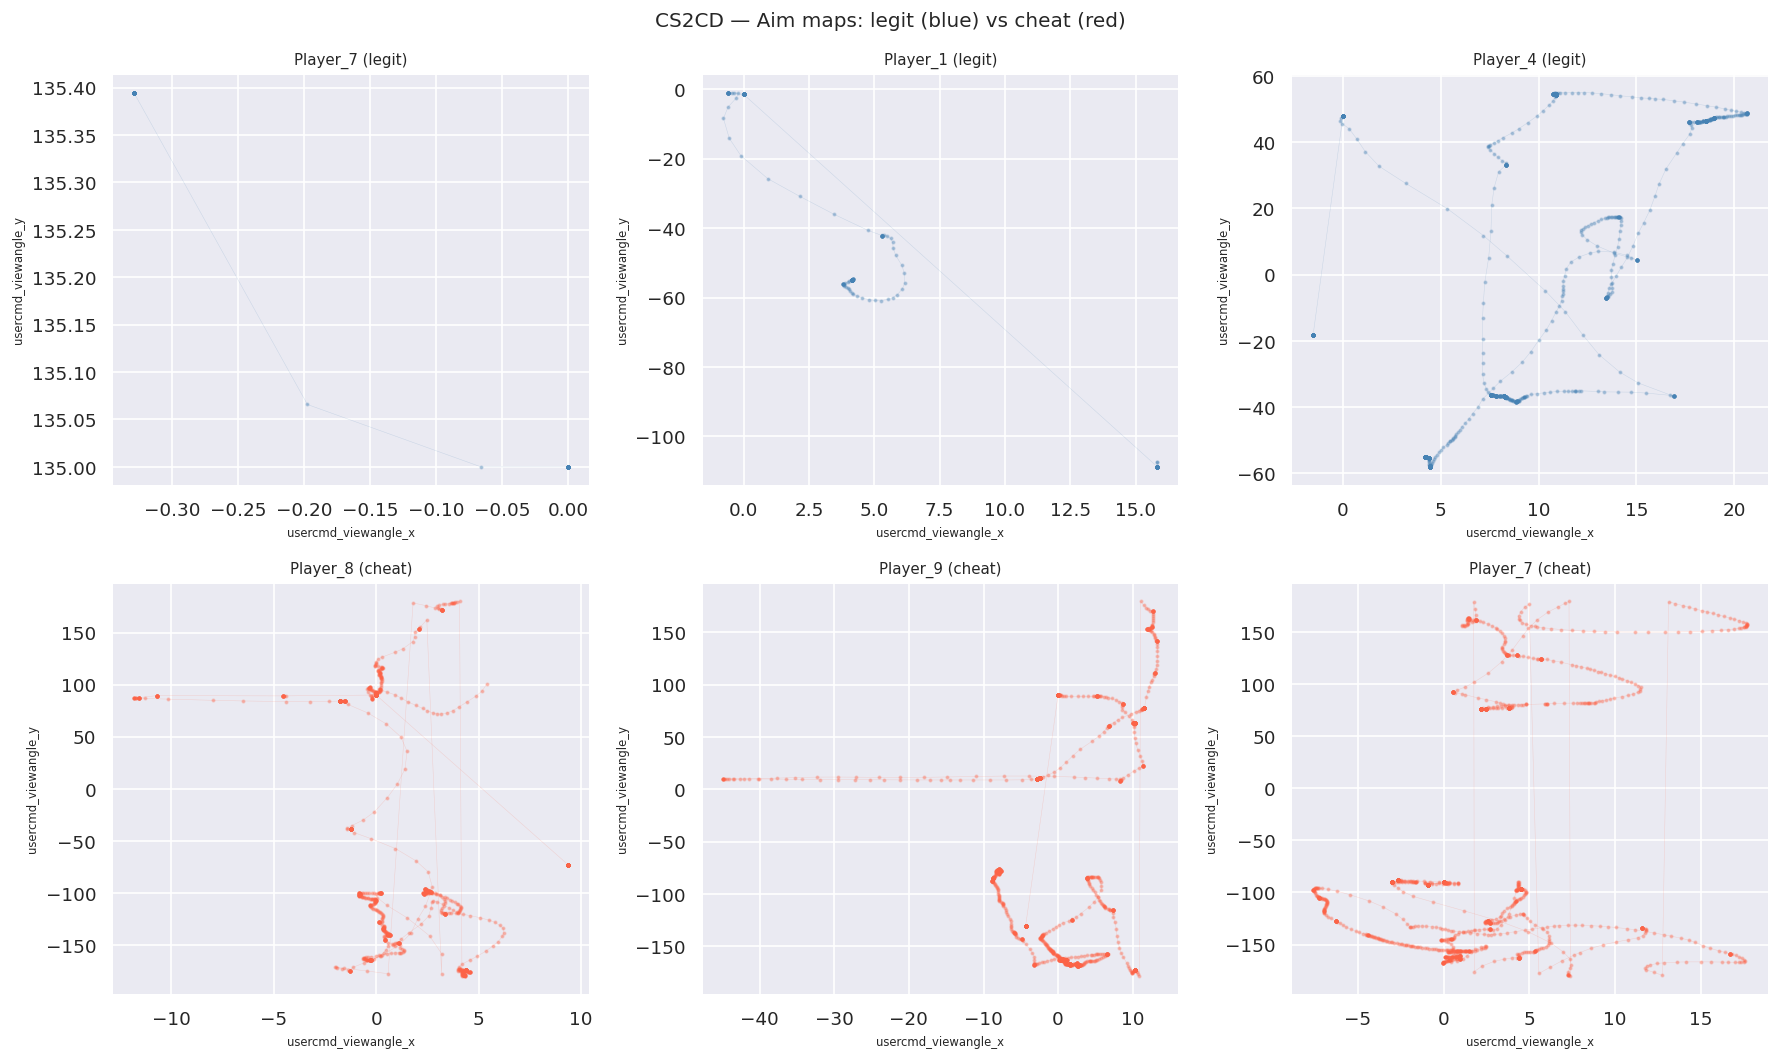

In [8]:
# Each steamid appears in BOTH legit and cheat rows (same players recorded in both
# match types). So group-by-mean gives every player a mean of ~0.5.
# Instead: pick the first 3 players from legit rows, first 3 from cheat rows,
# then filter each player's trajectory to only their respective label rows.
legit_players = cs2[cs2["cheater_present"] == 0]["steamid"].unique()[:3].tolist()
cheat_players = cs2[cs2["cheater_present"] == 1]["steamid"].unique()[:3].tolist()
print("Legit players:", legit_players)
print("Cheat players:", cheat_players)

selected = [(p, "legit", 0) for p in legit_players] + [(p, "cheat", 1) for p in cheat_players]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (player, label, label_val) in zip(axes, selected):
    sub = (
        cs2[(cs2["steamid"] == player) & (cs2["cheater_present"] == label_val)]
        .sort_values("tick")[[VIEW_X, VIEW_Y]]
        .dropna()
    )
    color = "steelblue" if label == "legit" else "tomato"
    ax.scatter(sub[VIEW_X], sub[VIEW_Y], s=2, alpha=0.3, c=color)
    ax.plot(sub[VIEW_X].values, sub[VIEW_Y].values, lw=0.3, alpha=0.2, c=color)
    ax.set_title(f"{player} ({label})", fontsize=9)
    ax.set_xlabel(VIEW_X, fontsize=7)
    ax.set_ylabel(VIEW_Y, fontsize=7)

for ax in axes[len(selected):]:
    ax.set_visible(False)

fig.suptitle("CS2CD — Aim maps: legit (blue) vs cheat (red)", fontsize=12)
plt.tight_layout()
plt.show()

---
## Section D — CaptchaSolve30k: Trajectory Overlays by Game Type

CaptchaSolve30k is human-only — no bot labels. Instead we compare **across game types**
as a proxy for different behavioral contexts. The three tasks have very different mouse demands:

- `thread-the-needle` — precision dragging along a narrow path → tight, controlled trajectories
- `polygon-stacking` — placing shapes → deliberate, slower movements
- `sheep-herding` — chasing a moving target → faster, more erratic movement

**Kinematic features + Kruskal-Wallis test — do game types produce different movement?**
Iterates over every CaptchaSolve30k session and computes five kinematic scalars via `session_kinematics()`. Then runs a **Kruskal-Wallis H-test** (non-parametric one-way ANOVA) for each feature across the three game types. A large H-statistic / small p-value means that feature is sensitive to task context — motivation for BehaviorDNA's game-specific features (`wasd_rhythm`, `burst_rate`).

In [9]:
# Compute kinematics for all sessions
print("Computing kinematics...")
records = []
for _, row in cap_raw.iterrows():
    r = session_kinematics(row.get("tickInputs"))
    if r is not None:
        r["game_type"] = row.get("gameType", "unknown")
        records.append(r)
cap = pd.DataFrame(records)
print(f"{len(cap):,} sessions with valid kinematics")

# Kruskal-Wallis test across game types for each kinematic feature
kinematic_features = ["speed_mean", "speed_std", "accel_mean", "accel_std", "jitter"]
game_types = cap["game_type"].unique()

kw_results = []
for feat in kinematic_features:
    groups = [cap[cap["game_type"] == gt][feat].dropna().values for gt in game_types]
    h_stat, p_val = stats.kruskal(*groups)
    kw_results.append({"feature": feat, "H_statistic": round(h_stat, 2), "p_value": f"{p_val:.2e}"})

print("\nKruskal-Wallis test — do kinematic features differ across game types?")
pd.DataFrame(kw_results).set_index("feature")

Computing kinematics...
20,000 sessions with valid kinematics

Kruskal-Wallis test — do kinematic features differ across game types?


,H_statistic,p_value
feature,,
speed_mean,11838.94,0.00e+00
speed_std,111.04,7.71e-25
accel_mean,9505.85,0.00e+00
accel_std,171.90,4.70e-38
jitter,10779.19,0.00e+00


**Trajectory overlays — raw mouse paths by game type.**
Samples 5 sessions per game type and draws the raw `(x, y)` pixel path recorded at 240 Hz. Black dot = start of session, coloured dot = end. Each game type uses a distinct colour (steelblue = thread-the-needle, seagreen = polygon-stacking, tomato = sheep-herding). Visual comparison shows how task structure constrains movement: tight precision paths vs. broad chasing arcs.

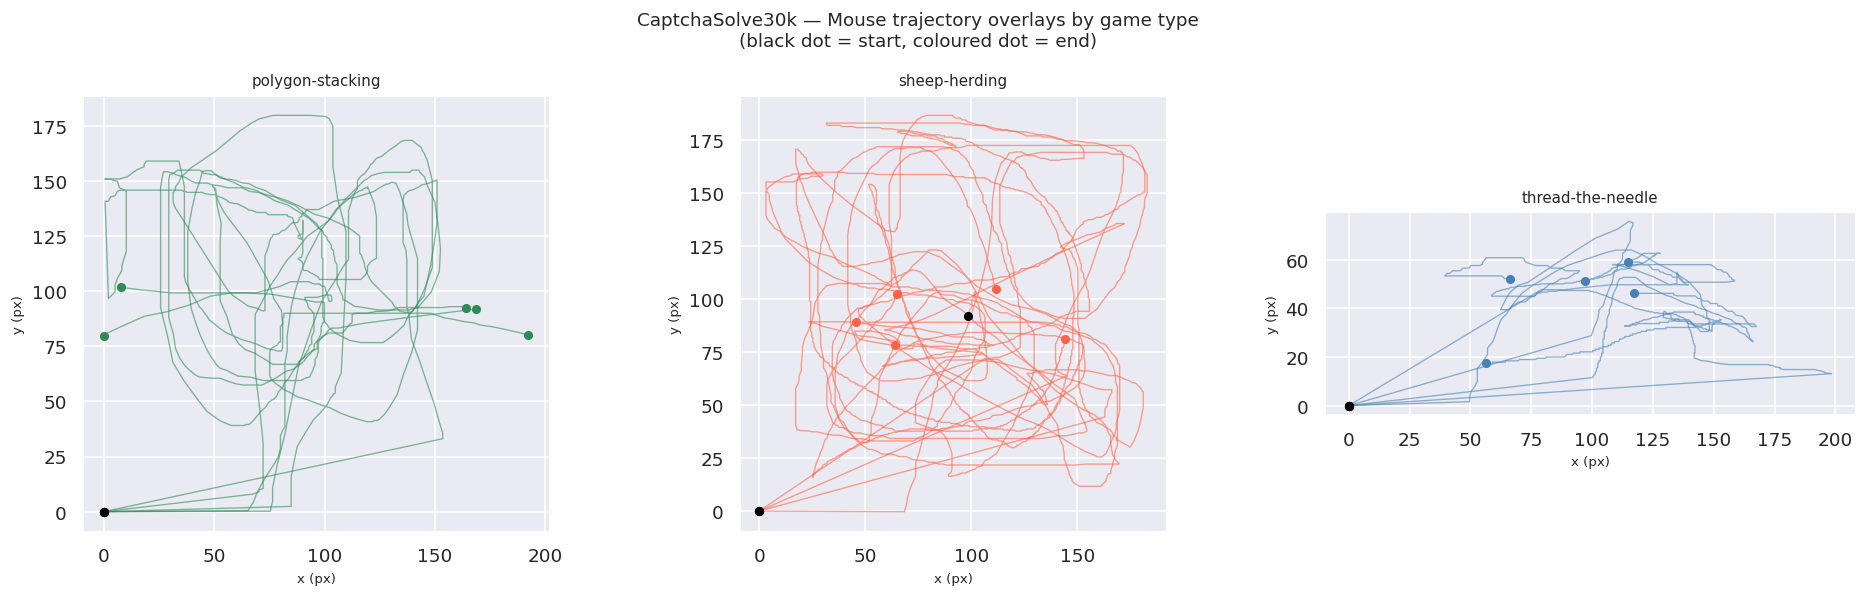

In [10]:
# Trajectory overlays — 5 sample sessions per game type
SAMPLES_PER_TYPE = 5
type_colors = {
    "thread-the-needle": "steelblue",
    "polygon-stacking":  "seagreen",
    "sheep-herding":     "tomato",
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, gt in zip(axes, sorted(game_types)):
    sample_rows = cap_raw[cap_raw["gameType"] == gt].sample(
        min(SAMPLES_PER_TYPE, (cap_raw["gameType"] == gt).sum()), random_state=42
    )
    color = type_colors.get(gt, "gray")
    for _, row in sample_rows.iterrows():
        ticks = row.get("tickInputs")
        if ticks is None or len(ticks) < 3:
            continue
        df_t = pd.DataFrame(list(ticks)).sort_values("sampleIndex")
        ax.plot(df_t["x"], df_t["y"], lw=0.8, alpha=0.6, color=color)
        ax.scatter(df_t["x"].iloc[0],  df_t["y"].iloc[0],  s=20, color="black", zorder=5)  # start
        ax.scatter(df_t["x"].iloc[-1], df_t["y"].iloc[-1], s=20, color=color,  zorder=5)  # end
    ax.set_title(gt, fontsize=9)
    ax.set_xlabel("x (px)", fontsize=8)
    ax.set_ylabel("y (px)", fontsize=8)
    ax.set_aspect("equal")

fig.suptitle(
    "CaptchaSolve30k — Mouse trajectory overlays by game type\n"
    "(black dot = start, coloured dot = end)",
    fontsize=11,
)
plt.tight_layout()
plt.show()

---
## Section E — Cross-Dataset Differentiation Summary

**Cross-dataset summary table.**
Joins the Mann-Whitney p-values (CS2CD cheat vs legit) and Kruskal-Wallis p-values (CaptchaSolve30k game type) for every feature that appears in either dataset or in BehaviorDNA's own `FEATURE_COLS`. Features present in BehaviorDNA are marked ✓. A `—` means the feature does not exist in that dataset. Kinematic features (`speed_mean`, `speed_std`, `accel_mean`, `accel_std`, `jitter`) bridge both datasets and all show highly significant differences (p ≈ 0).

In [11]:
# Build cross-dataset summary table
kw_lookup = {r["feature"]: r["p_value"] for r in kw_results}
mw_lookup  = dict(zip(
    pd.DataFrame(results).sort_values("effect_size", ascending=False)["feature"],
    pd.DataFrame(results).sort_values("effect_size", ascending=False)["p_value"].map("{:.2e}".format)
))

all_feats = sorted(set(FEATURE_COLS) | set(kinematic_features))
summary_rows = []
for f in all_feats:
    summary_rows.append({
        "feature":              f,
        "in BehaviorDNA":       "✓" if f in FEATURE_COLS else "",
        "CS2CD p-val (MWU)":    mw_lookup.get(f, "—"),
        "CaptchaSolve30k p-val (KW)": kw_lookup.get(f, "—"),
    })

pd.DataFrame(summary_rows).set_index("feature")

,in BehaviorDNA,CS2CD p-val (MWU),CaptchaSolve30k p-val (KW)
feature,,,
accel_mean,✓,—,0.00e+00
accel_std,✓,—,4.70e-38
active_time_pct,✓,—,—
burst_rate,✓,—,—
click_interval_mean,✓,—,—
click_interval_std,✓,—,—
event_rate,✓,—,—
hold_mean,✓,—,—
hold_std,✓,—,—


### Key Takeaways

*(Fill in after running the analysis)*

**CS2CD cheat detection:** The Mann-Whitney effect sizes reveal which per-tick signals
most consistently differ between matches with and without cheaters.
BehaviorDNA-adjacent features (`yaw`, `pitch`, `usercmd_mouse_dx/dy`) appearing in the
top-20 validate that raw input signals carry discriminative power — not just outcome metrics.

**PCA vs UMAP:** PCA shows whether variance aligns with the cheat label (linear separability).
UMAP reveals cluster structure invisible to PCA — tighter separation there indicates the
feature space has non-linear discriminative structure worth exploiting.

**Aim maps:** Visual inspection of view-angle trajectories shows whether cheat patterns
are mechanically distinct (smooth aimbot sweeps vs. organic human scatter).

**CaptchaSolve30k game types:** The Kruskal-Wallis H-statistic quantifies how much task
context shapes mouse kinematics — confirming that behavioral signals are context-dependent
and that BehaviorDNA's game-specific features (`wasd_rhythm`, `burst_rate`) are well-motivated.